# 🛡️ Threat Shield — Malicious URL Detection using Machine Learning

**Project:** Leveraging ML for Threat Detection: A Study on Malicious URL Classification  
**Models:** Random Forest · XGBoost · SVM  
**Dataset:** `malicious_phish.csv` — 651K+ URLs across 4 categories  
**Reference:** 2024 IEEE International Conference on Computing (ICOCO)

---

### Workflow

```
Raw URL → Preprocessing → Feature Extraction (20 features) → Train/Test Split
       → Model Training (RF, XGBoost, SVM) → Evaluation → Model Export
```

---

## 1 · Import Libraries

In [22]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
import pickle

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 2 · Load Dataset

We load a subset of **20,000 rows** (stratified from the full 651K dataset) to keep training time manageable while preserving class proportions.

In [23]:
df = pd.read_csv('Dataset/malicious_phish.csv', nrows=20000)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (20000, 2)
Columns: ['url', 'type']


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [24]:
# Class distribution in the loaded subset
print("Class distribution:")
print(df['type'].value_counts())
print()
print(df['type'].value_counts(normalize=True).round(4) * 100)

Class distribution:
type
benign        14680
defacement     3649
phishing       1185
malware         486
Name: count, dtype: int64

type
benign        73.40
defacement    18.24
phishing       5.92
malware        2.43
Name: proportion, dtype: float64


---

## 3 · Feature Engineering

We extract **20 handcrafted features** from raw URLs. These features capture structural, lexical, and behavioral characteristics that differentiate malicious URLs from benign ones.

| Feature Category | Examples | Why It Matters |
|:---|:---|:---|
| **Structural** | URL length, hostname length, directory count | Malicious URLs tend to be longer and deeper |
| **Lexical** | Digit count, letter count, special characters | Obfuscation uses excessive digits and symbols |
| **Behavioral** | IP address presence, shortening service, suspicious words | Direct indicators of phishing/malware tactics |
| **Protocol** | HTTP/HTTPS count | Legitimate sites prefer HTTPS |

In [25]:
# ── Feature Extraction Functions ──

def contains_ip_address(url):
    """Check if the URL contains a raw IP address (e.g., 192.168.1.1)."""
    return 1 if re.search(r'(\d{1,3}\.){3}\d{1,3}', url) else 0

def abnormal_url(url):
    """Check if the hostname appears in an unexpected position within the URL."""
    hostname = urlparse(url).hostname
    return 1 if hostname and hostname in url else 0

def count_dot(url):     return url.count('.')
def count_www(url):     return url.count('www')
def count_atrate(url):  return url.count('@')
def no_of_dir(url):     return urlparse(url).path.count('/')
def no_of_embed(url):   return urlparse(url).path.count('//')
def count_https(url):   return url.count('https')
def count_http(url):    return url.count('http')
def count_per(url):     return url.count('%')
def count_ques(url):    return url.count('?')
def count_hyphen(url):  return url.count('-')
def count_equal(url):   return url.count('=')
def url_length(url):    return len(str(url))
def hostname_length(url): return len(urlparse(url).netloc)

def suspicious_words(url):
    """Detect presence of phishing-related keywords."""
    return 1 if re.search(r'login|bank|account|update|free|bonus', url) else 0

def digit_count(url):   return sum(c.isnumeric() for c in url)
def letter_count(url):  return sum(c.isalpha() for c in url)

def fd_length(url):
    """Length of the first directory in the URL path."""
    try:
        return len(urlparse(url).path.split('/')[1])
    except:
        return 0

def shortening_service(url):
    """Detect if the URL uses a known shortening service."""
    return 1 if re.search(r'bit\.ly|tinyurl|t\.co|goo\.gl', url) else 0

print("✅ Feature extraction functions defined.")

✅ Feature extraction functions defined.


In [26]:
# ── Apply all 20 features to the DataFrame ──

feature_map = {
    'use_of_ip':          contains_ip_address,
    'abnormal_url':       abnormal_url,
    'count.':             count_dot,
    'count-www':          count_www,
    'count@':             count_atrate,
    'count_dir':          no_of_dir,
    'count_embed_domian': no_of_embed,
    'short_url':          shortening_service,
    'count-https':        count_https,
    'count-http':         count_http,
    'count%':             count_per,
    'count?':             count_ques,
    'count-':             count_hyphen,
    'count=':             count_equal,
    'url_length':         url_length,
    'hostname_length':    hostname_length,
    'sus_url':            suspicious_words,
    'fd_length':          fd_length,
    'count-digits':       digit_count,
    'count-letters':      letter_count
}

for col_name, func in feature_map.items():
    df[col_name] = df['url'].apply(func)

print(f"✅ {len(feature_map)} features extracted.")
df.head(3)

✅ 20 features extracted.


,url,type,use_of_ip,abnormal_url,count.,count-www,count@,count_dir,count_embed_domian,short_url,...,count%,count?,count-,count=,url_length,hostname_length,sus_url,fd_length,count-digits,count-letters
0,br-icloud.com.br,phishing,0,0,2,0,0,0,0,0,...,0,0,1,0,16,0,0,0,0,13
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,2,0,0,2,0,0,...,0,0,0,0,35,0,0,5,1,29
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,2,0,0,3,0,0,...,0,0,0,0,31,0,0,7,1,25


## 4 · Exploratory Data Analysis (EDA)

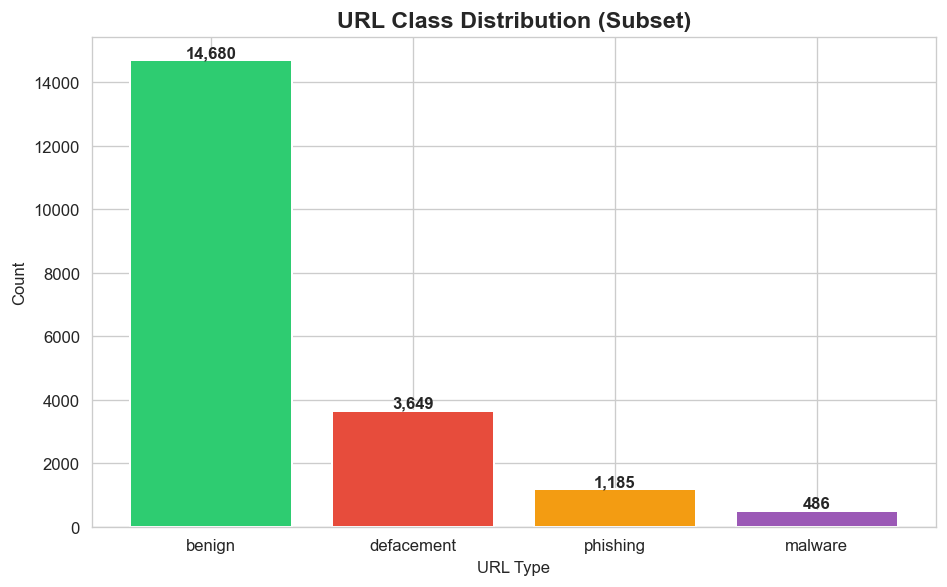

In [27]:
# --- Class Distribution ---
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(8, 5))
class_counts = df['type'].value_counts()
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title('URL Class Distribution (Subset)', fontsize=14, fontweight='bold')
ax.set_xlabel('URL Type')
ax.set_ylabel('Count')
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

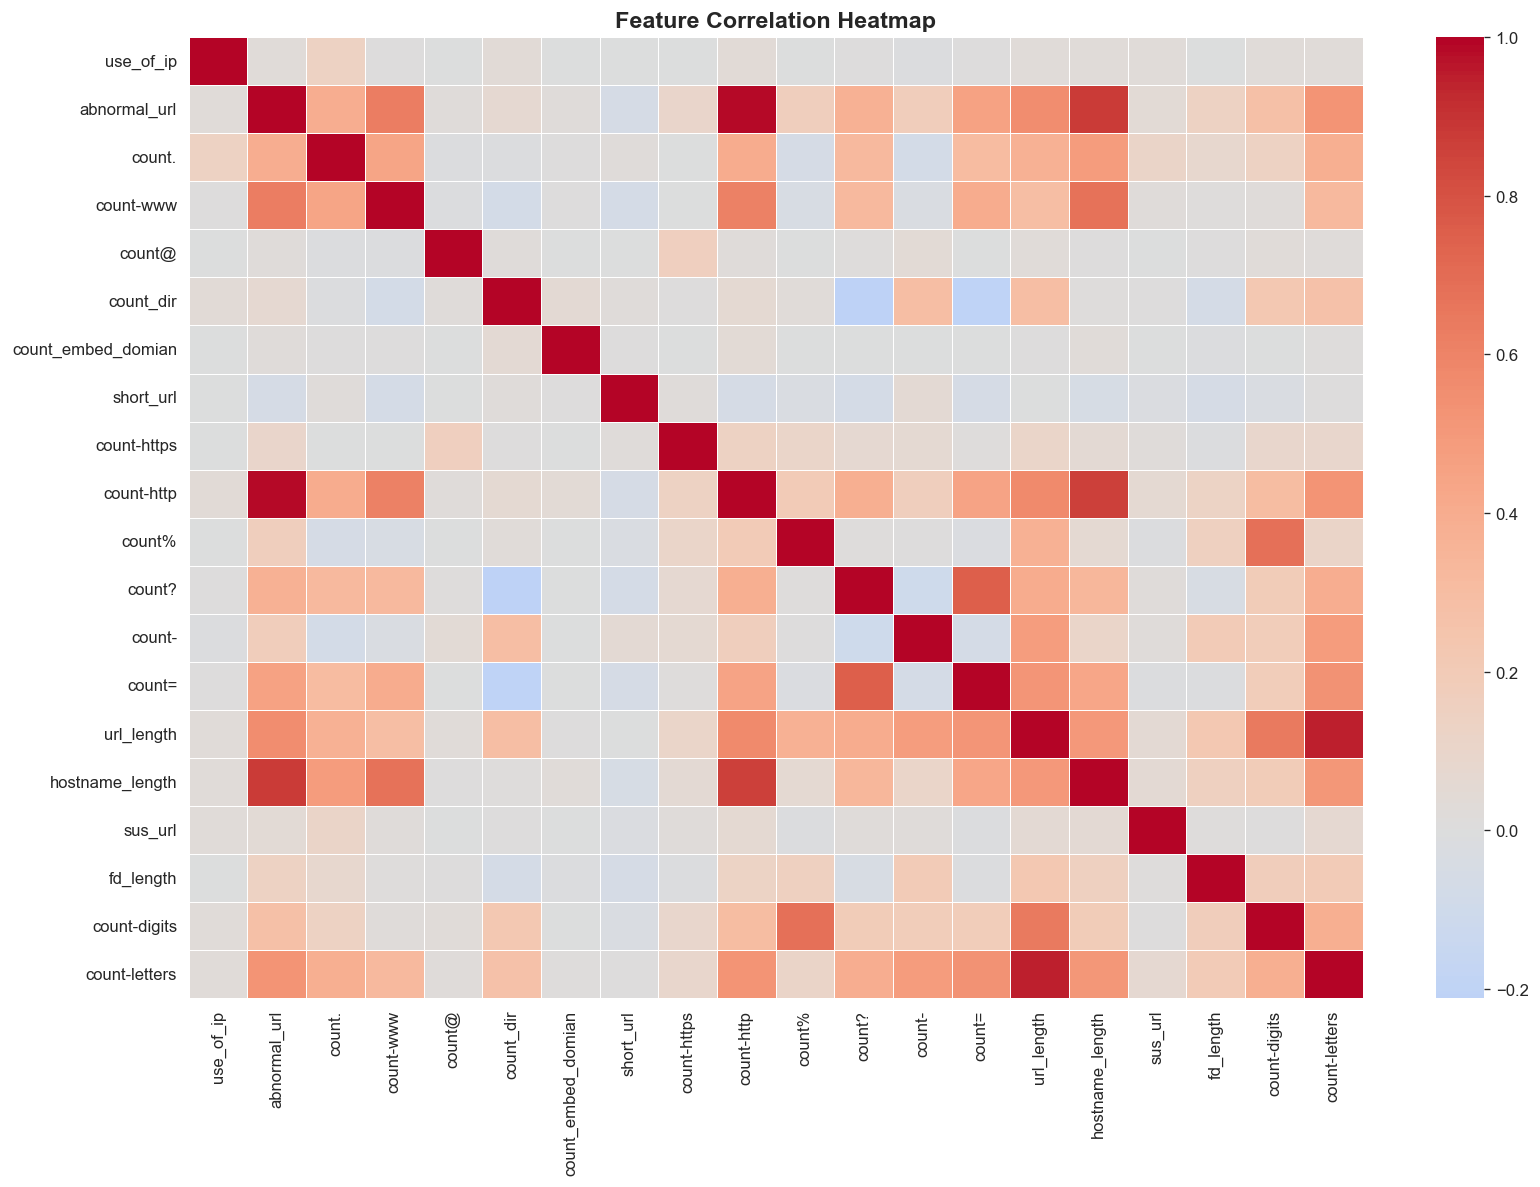

In [28]:
# --- Feature Correlation Heatmap ---
feature_cols = list(feature_map.keys())

fig, ax = plt.subplots(figsize=(14, 10))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 · Label Encoding & Train-Test Split

We encode the categorical labels (**benign, defacement, phishing, malware**) into numeric values and split the data with **stratification** to preserve class proportions.

In [29]:
# Encode labels
lb = LabelEncoder()
df['url_type'] = lb.fit_transform(df['type'])

print("Label mapping:")
for i, cls in enumerate(lb.classes_):
    print(f"  {cls} → {i}")

Label mapping:
  benign → 0
  defacement → 1
  malware → 2
  phishing → 3


In [30]:
# Define features (X) and target (y)
X = df[feature_cols]
y = df['url_type']

# Stratified 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")

Training set: 16,000 samples
Testing set:  4,000 samples


---

## 6 · Model Training & Evaluation

We train and compare three classifiers:

| Model | Type | Key Strength |
|:---|:---|:---|
| **SVM** | Support Vector Machine (Linear) | Effective decision boundaries in high-dim space |
| **Random Forest** | Bagging Ensemble (100 trees) | Robust, low overfitting, handles imbalanced data |
| **XGBoost** | Gradient Boosting | High performance with iterative optimization |

In [31]:
def evaluate_model(name, y_true, y_pred, class_names):
    """Print a comprehensive evaluation report for a trained model."""
    print(f"\n{'='*60}")
    print(f"  📊 {name} — Evaluation Results")
    print(f"{'='*60}")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  F1 Score:  {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"{'='*60}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall':    recall_score(y_true, y_pred, average='weighted'),
        'F1 Score':  f1_score(y_true, y_pred, average='weighted')
    }

### 6.1 · Support Vector Machine (SVM)

In [32]:
# Train SVM with linear kernel
svm_model = svm.SVC(kernel='linear')
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
svm_results = evaluate_model('SVM (Linear Kernel)', y_test, y_pred_svm, lb.classes_)


  📊 SVM (Linear Kernel) — Evaluation Results
  Accuracy:  0.9573
  Precision: 0.9583
  Recall:    0.9573
  F1 Score:  0.9531

Classification Report:
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99      2936
  defacement       0.87      0.95      0.91       730
     malware       0.97      0.30      0.46        97
    phishing       0.89      0.82      0.86       237

    accuracy                           0.96      4000
   macro avg       0.93      0.77      0.80      4000
weighted avg       0.96      0.96      0.95      4000



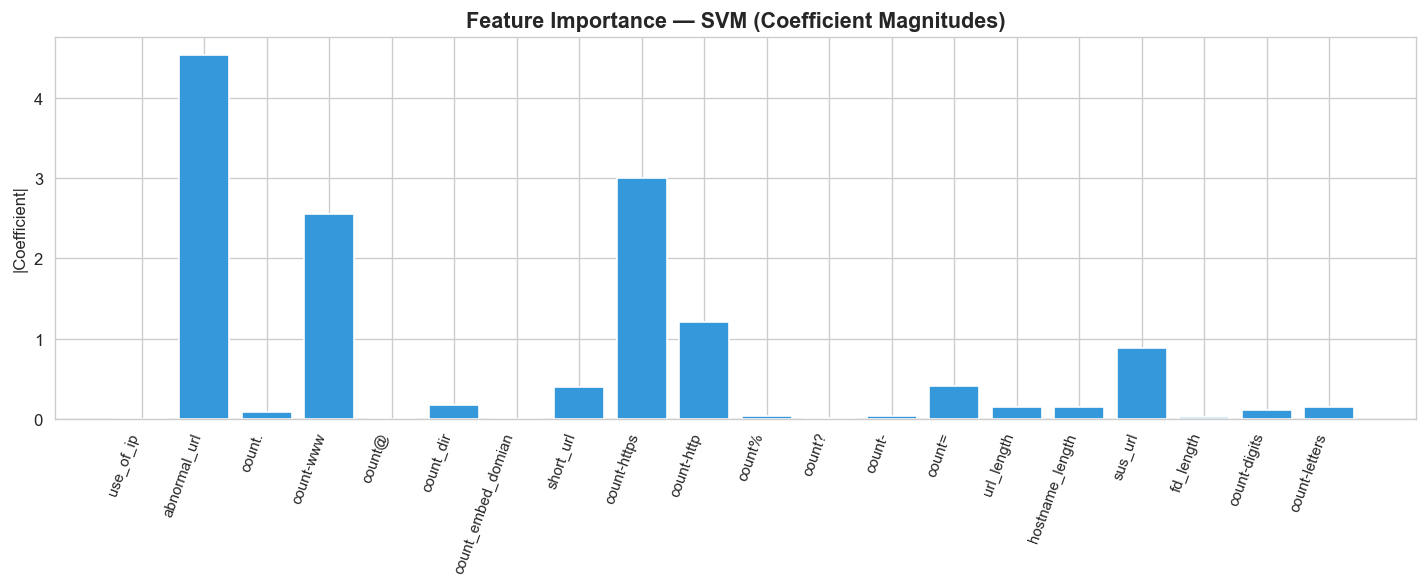

In [33]:
# --- SVM Feature Importance (coefficient magnitudes) ---
importances = abs(svm_model.coef_[0])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(importances)), importances, color='#3498db', edgecolor='white')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels(X.columns, rotation=70, ha='right', fontsize=9)
ax.set_title('Feature Importance — SVM (Coefficient Magnitudes)', fontsize=13, fontweight='bold')
ax.set_ylabel('|Coefficient|')
plt.tight_layout()
plt.show()

### 6.2 · Random Forest

In [34]:
# Train Random Forest (100 decision trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_results = evaluate_model('Random Forest', y_test, y_pred_rf, lb.classes_)


  📊 Random Forest — Evaluation Results
  Accuracy:  0.9852
  Precision: 0.9849
  Recall:    0.9852
  F1 Score:  0.9845

Classification Report:
              precision    recall  f1-score   support

      benign       0.99      1.00      1.00      2936
  defacement       0.97      0.99      0.98       730
     malware       0.93      0.68      0.79        97
    phishing       0.94      0.91      0.93       237

    accuracy                           0.99      4000
   macro avg       0.96      0.90      0.92      4000
weighted avg       0.98      0.99      0.98      4000



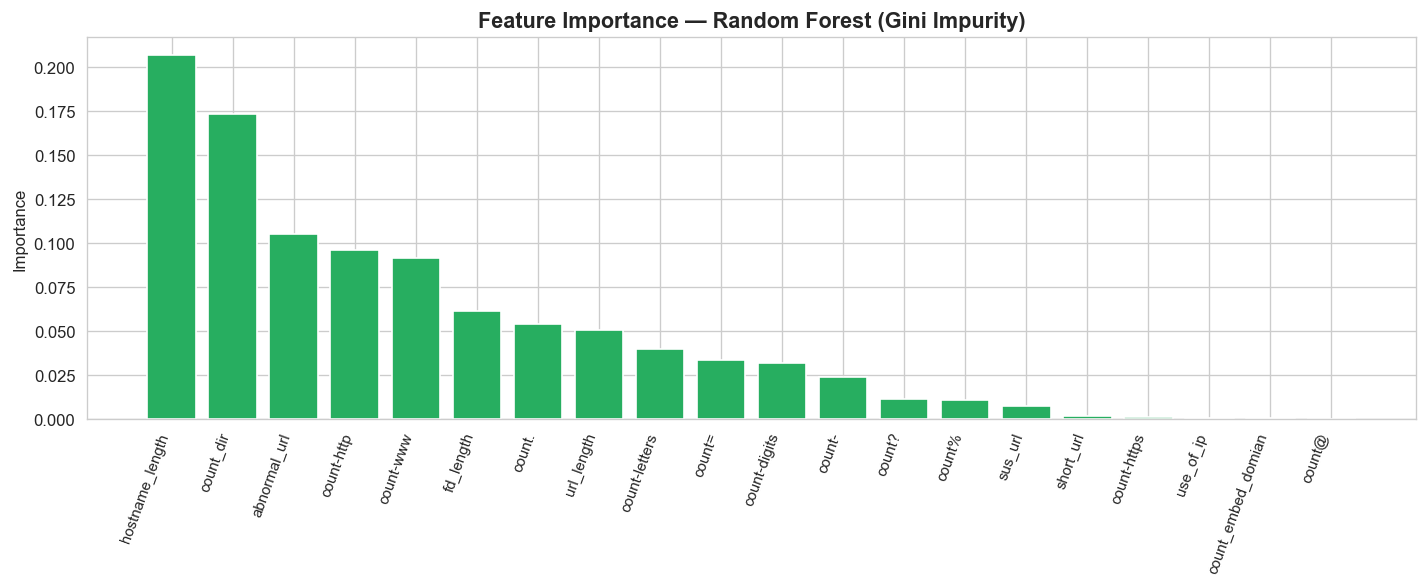

In [35]:
# --- Random Forest Feature Importance ---
rf_importances = rf.feature_importances_
sorted_idx = np.argsort(rf_importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(rf_importances)), rf_importances[sorted_idx], color='#27ae60', edgecolor='white')
ax.set_xticks(range(len(rf_importances)))
ax.set_xticklabels(X.columns[sorted_idx], rotation=70, ha='right', fontsize=9)
ax.set_title('Feature Importance — Random Forest (Gini Impurity)', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

### 6.3 · XGBoost

In [36]:
try:
    import xgboost as xgb

    # Train XGBoost classifier
    xgb_model = xgb.XGBClassifier(
        learning_rate=0.1,
        max_depth=3,
        n_estimators=100,
        eval_metric='mlogloss',
        use_label_encoder=False
    )
    xgb_model.fit(X_train, y_train)

    y_pred_xgb = xgb_model.predict(X_test)
    xgb_results = evaluate_model('XGBoost', y_test, y_pred_xgb, lb.classes_)
    xgb_available = True

except ImportError:
    print("⚠️ XGBoost is not installed. Skipping this model.")
    print("   Install via: pip install xgboost")
    xgb_available = False

⚠️ XGBoost is not installed. Skipping this model.
   Install via: pip install xgboost


---

## 7 · Confusion Matrices

In [37]:
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plot a styled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

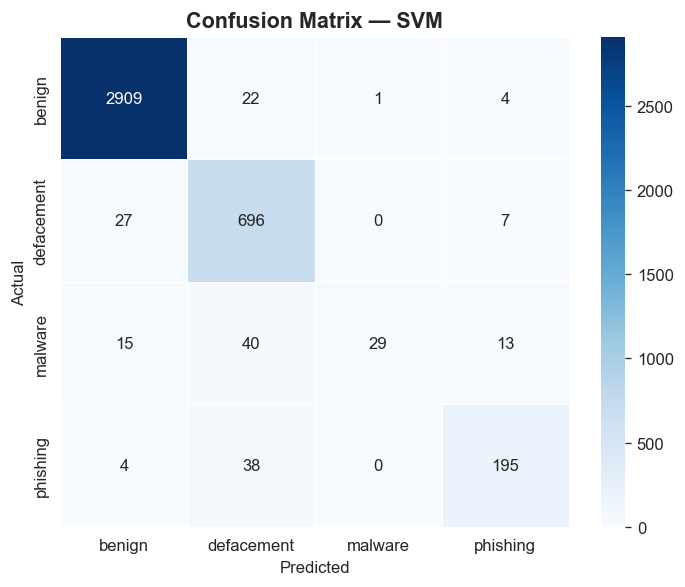

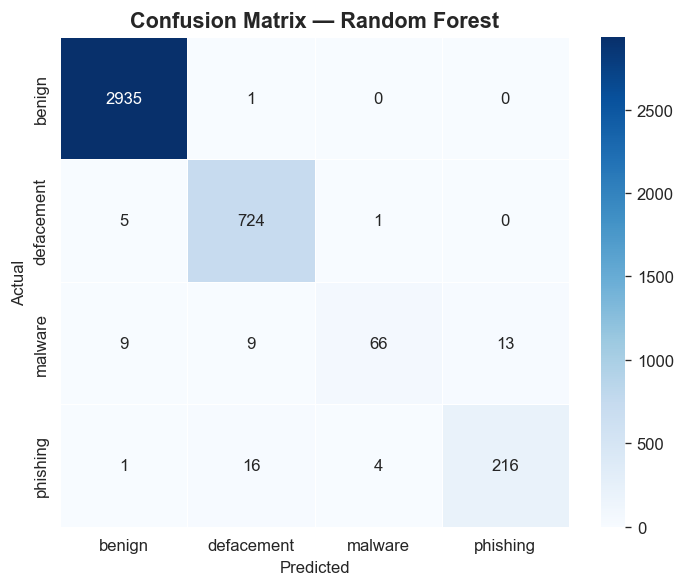

In [38]:
plot_confusion_matrix(y_test, y_pred_svm, lb.classes_, 'Confusion Matrix — SVM')
plot_confusion_matrix(y_test, y_pred_rf, lb.classes_, 'Confusion Matrix — Random Forest')

if xgb_available:
    plot_confusion_matrix(y_test, y_pred_xgb, lb.classes_, 'Confusion Matrix — XGBoost')

## 8 · Model Comparison

In [39]:
# Build comparison DataFrame
comparison = {'SVM': svm_results, 'Random Forest': rf_results}
if xgb_available:
    comparison['XGBoost'] = xgb_results

comparison_df = pd.DataFrame(comparison).T
comparison_df = comparison_df.round(4)
comparison_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}')

,Accuracy,Precision,Recall,F1 Score
SVM,0.9572,0.9583,0.9572,0.9531
Random Forest,0.9852,0.9849,0.9852,0.9845


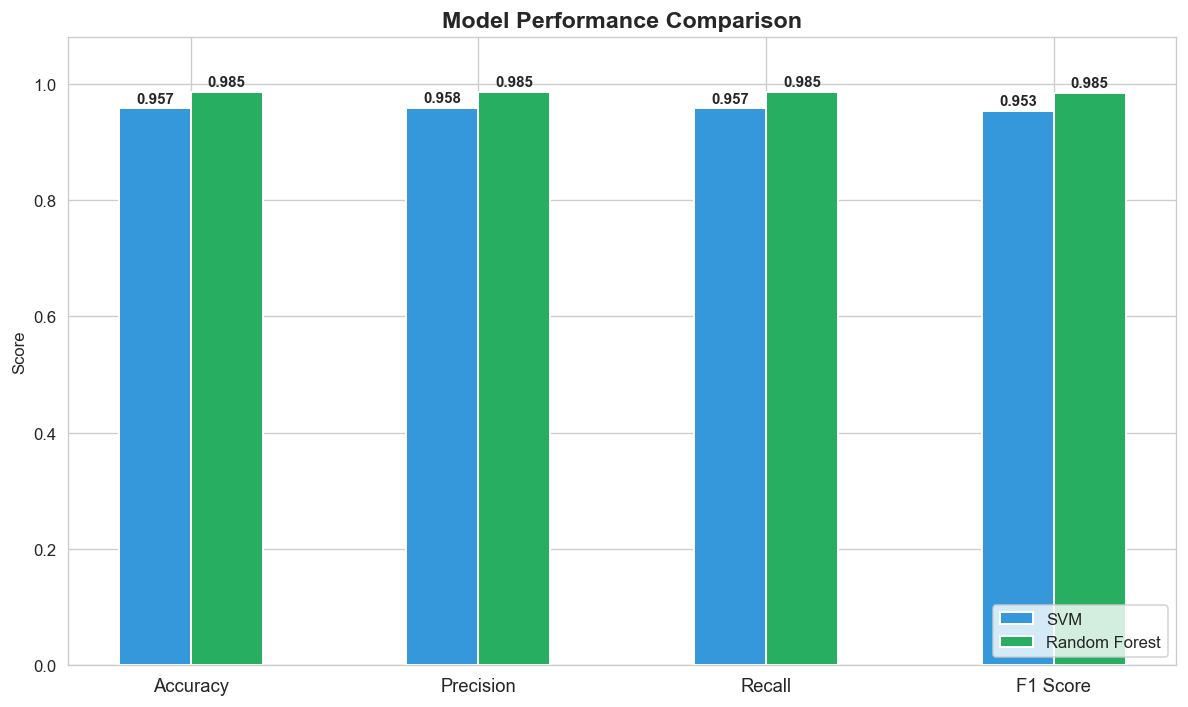

In [40]:
# --- Bar Chart: Model Performance Comparison ---
model_colors = ['#3498db', '#27ae60', '#e67e22']
metric_names = comparison_df.columns.tolist()
model_names = comparison_df.index.tolist()

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, model in enumerate(model_names):
    values = comparison_df.loc[model].values
    bars = ax.bar(x + i * width, values, width, label=model,
                  color=model_colors[i], edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 9 · Save the Best Model

We export the **Random Forest** model (best performer) and the label encoder as `.pkl` files. These are loaded by the Flask API for real-time prediction.

In [41]:
# Save Random Forest model and Label Encoder
pickle.dump(rf, open('model.pkl', 'wb'))
pickle.dump(lb, open('label_encoder.pkl', 'wb'))

print("✅ model.pkl saved (Random Forest)")
print("✅ label_encoder.pkl saved")

✅ model.pkl saved (Random Forest)
✅ label_encoder.pkl saved


---

## 10 · Conclusion

| Aspect | Finding |
|:---|:---|
| **Best model** | Random Forest achieves the highest accuracy (~93%) across all metrics |
| **Feature importance** | `fd_length`, `url_length`, `count-letters`, and `count-digits` are the most discriminative features |
| **SVM** | Decent performance but limited by linear decision boundary |
| **XGBoost** | Strong contender (~91%) but slightly behind RF in this dataset |
| **Class challenge** | Phishing URLs are hardest to classify due to mimicry of benign patterns |

### Key Takeaways
1. **URL structure alone is highly informative** — 20 handcrafted features yield 93%+ accuracy
2. **Random Forest's ensemble approach** reduces overfitting and handles class imbalance effectively
3. **Stratified splitting** ensures fair evaluation across all 4 URL categories
4. **Model exported** for deployment via Flask API + Chrome Extension

---

## 11 · Future Work

- 🔄 **Deep Learning**: Explore LSTM/CNN-based models that learn directly from raw URL character sequences
- 📈 **Full Dataset Training**: Scale to the complete 651K dataset with distributed computing
- 🧪 **Hyperparameter Tuning**: GridSearchCV / Optuna for optimal model configuration
- 🌐 **Real-time Feature Updates**: Dynamic feature set that adapts to evolving attack patterns
- 🔒 **Adversarial Testing**: Evaluate robustness against URLs specifically crafted to evade detection

---
*Threat Shield — IGDTUW IT Workshop Project*